# Projet Time Series — Problème 2
## Monthly Airline Passengers (1949–1960)



## 0. Imports et chargement des données

In [205]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox

print("Imports OK")

Imports OK


In [298]:
import os

CSV_PATH = r"C:\Users\iyadb\Bureau\IDSCC S4\TIME SERIES\projet\airline_passengers.csv"

df = pd.read_csv(CSV_PATH)
df.head()

,Unnamed: 0,passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


In [300]:
date_col  = df.columns[0]   
value_col = df.columns[1]   


df[date_col] = pd.to_datetime(df[date_col])
df = df.set_index(date_col)
df.index.freq = pd.infer_freq(df.index)

series = df[value_col].rename('passengers')

print(f"Colonne date   : {date_col}")
print(f"Colonne valeur : {value_col}")
print(f"Observations   : {len(series)}")
print(f"Période        : {series.index[0].date()} -> {series.index[-1].date()}")
print()
print(series.describe().round(2))

Colonne date   : Unnamed: 0
Colonne valeur : passengers
Observations   : 144
Période        : 1949-01-01 -> 1960-12-01

count    144.00
mean     280.30
std      119.97
min      104.00
25%      180.00
50%      265.50
75%      360.50
max      622.00
Name: passengers, dtype: float64


---
## 1. Analyse Exploratoire

### 1.1 Statistiques descriptives

Définitions formelles :
$$\bar{y} = \frac{1}{n}\sum y_t \qquad s^2 = \frac{1}{n-1}\sum(y_t-\bar{y})^2 \qquad s = \sqrt{s^2}$$


In [303]:
n     = len(series)
mu    = series.mean()
sigma = series.std()
var   = series.var()

print(f"n     = {n}")
print(f"μ     = {mu:.2f}")
print(f"σ²    = {var:.2f}")
print(f"σ     = {sigma:.2f}")
print(f"Min   = {series.min()}")
print(f"Max   = {series.max()}")
print(f"Med   = {series.median()}")

n     = 144
μ     = 280.30
σ²    = 14391.92
σ     = 119.97
Min   = 104
Max   = 622
Med   = 265.5


### 1.2 Visualisation de la série brute

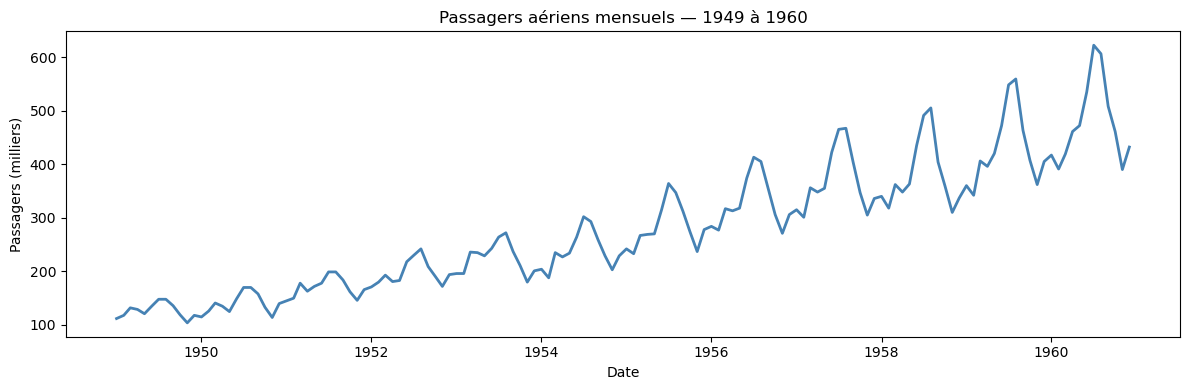

In [306]:
plt.figure(figsize=(12, 4))
plt.plot(series, color='steelblue', lw=2)
plt.title('Passagers aériens mensuels — 1949 à 1960')
plt.ylabel('Passagers (milliers)')
plt.xlabel('Date')
plt.tight_layout()
plt.show()

# Interprétation :
# - Tendance croissante nette
# - Saisonnalité annuelle (pics en été, creux en hiver)
# - Variance qui augmente avec le niveau -> comportement MULTIPLICATIF

### 1.3 Distribution mensuelle (saisonnalité)

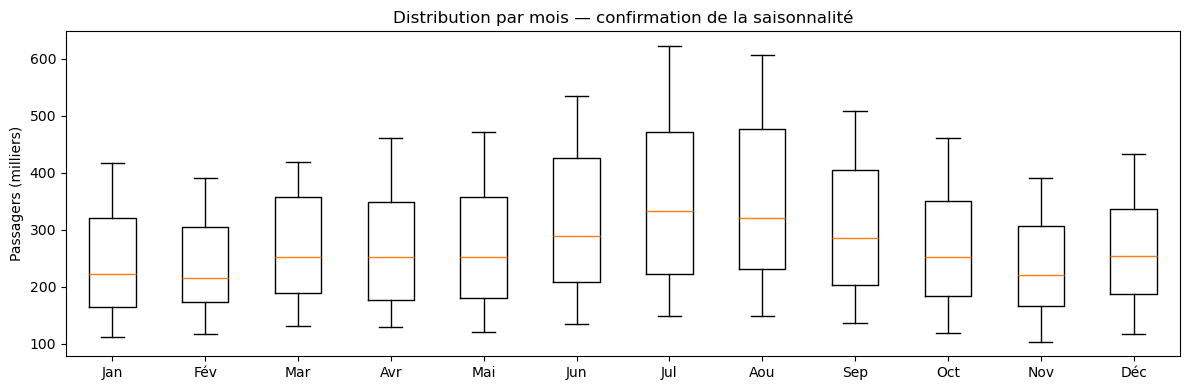

In [309]:
mois_labels = ['Jan','Fév','Mar','Avr','Mai','Jun',
               'Jul','Aou','Sep','Oct','Nov','Déc']

# Regrouper par mois
groupes = [series[series.index.month == m].values for m in range(1, 13)]

plt.figure(figsize=(12, 4))
plt.boxplot(groupes, labels=mois_labels)
plt.title('Distribution par mois — confirmation de la saisonnalité')
plt.ylabel('Passagers (milliers)')
plt.tight_layout()
plt.show()

# Juillet et Aout = pics; Janvier–Février = creux

### 1.4 Décomposition (additif vs multiplicatif)

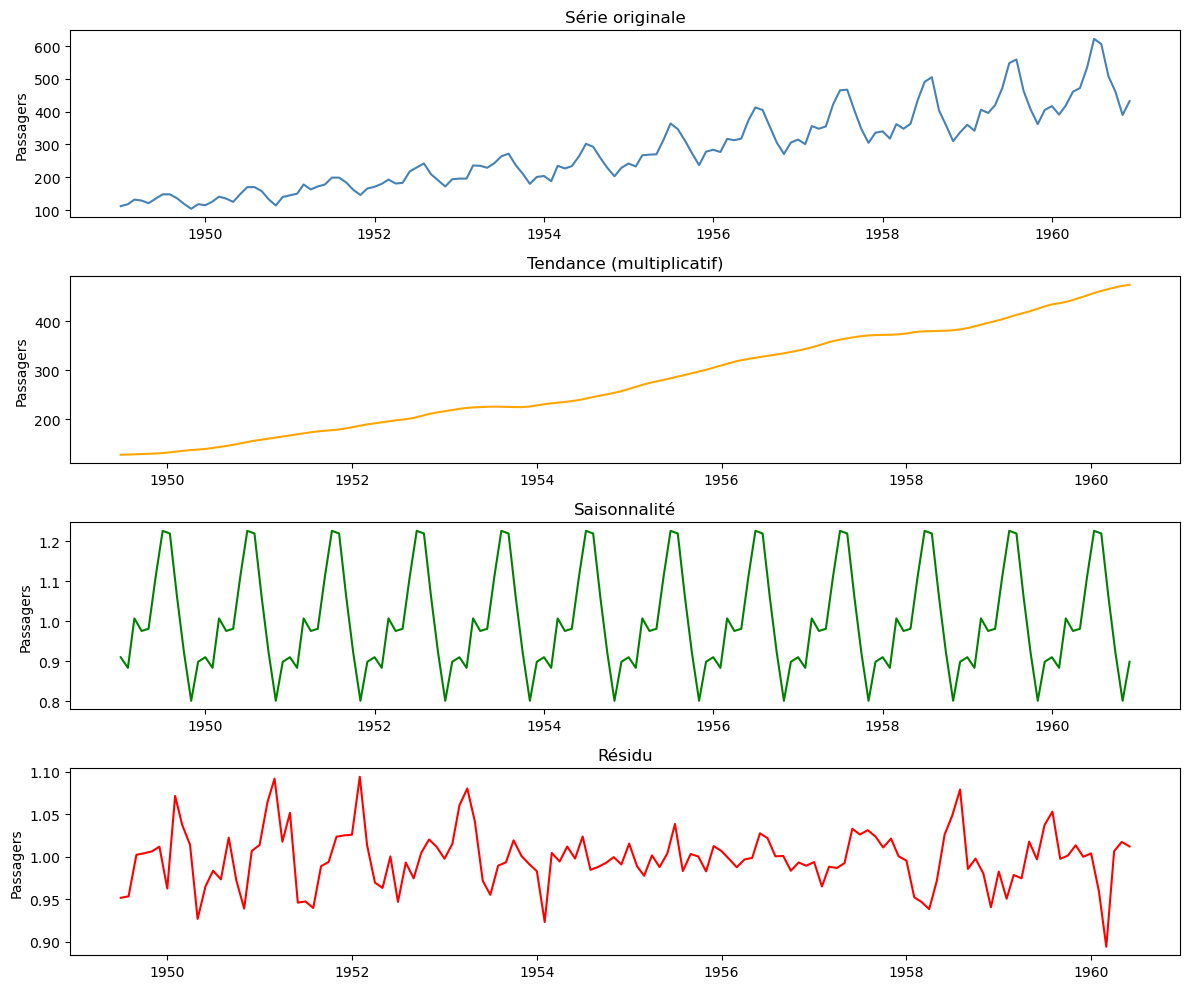

In [312]:
# Modèle additif : y_t = T_t + S_t + R_t
# Modèle multiplicatif : y_t = T_t × S_t × R_t
# Pour cette série, la variance croît avec la tendance 

decomp_add  = seasonal_decompose(series, model='additive',     period=12)
decomp_mult = seasonal_decompose(series, model='multiplicative', period=12)

fig, axes = plt.subplots(4, 1, figsize=(12, 10))
axes[0].plot(series,            color='steelblue'); axes[0].set_title('Série originale')
axes[1].plot(decomp_mult.trend, color='orange');   axes[1].set_title('Tendance (multiplicatif)')
axes[2].plot(decomp_mult.seasonal, color='green'); axes[2].set_title('Saisonnalité')
axes[3].plot(decomp_mult.resid, color='red');      axes[3].set_title('Résidu')
for ax in axes:
    ax.set_ylabel('Passagers')
plt.tight_layout()
plt.show()

---
## 2. Transformation et Préparation

### 2.1 Tests de stationnarité (série brute)

**ADF** : H₀ = racine unité (non stationnaire) -> rejeter si p < 0.05  
**KPSS** : H₀ = stationnaire -> rejeter si p < 0.05


In [315]:
import warnings
from statsmodels.tools.sm_exceptions import InterpolationWarning

def test_stationnarite(s, label):
    adf_stat, adf_p, _, _, _, _ = adfuller(s.dropna(), autolag='AIC')

    # InterpolationWarning = statistique hors table → p-value encore plus petite, pas un problème
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', InterpolationWarning)
        kpss_stat, kpss_p, _, _ = kpss(s.dropna(), regression='c', nlags='auto')

    verdict_adf  = 'STATIONNAIRE'  if adf_p  < 0.05 else 'NON STATIONNAIRE'
    verdict_kpss = 'STATIONNAIRE'  if kpss_p > 0.05 else 'NON STATIONNAIRE'

    print(f'--- {label} ---')
    print(f'  ADF  : stat={adf_stat:.3f}, p={adf_p:.4f}  : {verdict_adf}')
    print(f'  KPSS : stat={kpss_stat:.3f}, p={kpss_p:.4f}  : {verdict_kpss}')
    if kpss_p <= 0.01:
        print(f'  (KPSS : p-value plancher 0.01, vraie valeur encore plus petite -> non stationnaire confirmé)')
    print()

test_stationnarite(series, 'Série brute')

--- Série brute ---
  ADF  : stat=0.815, p=0.9919  : NON STATIONNAIRE
  KPSS : stat=1.651, p=0.0100  : NON STATIONNAIRE
  (KPSS : p-value plancher 0.01, vraie valeur encore plus petite -> non stationnaire confirmé)



### 2.2 Transformation logarithmique (stabiliser la variance)

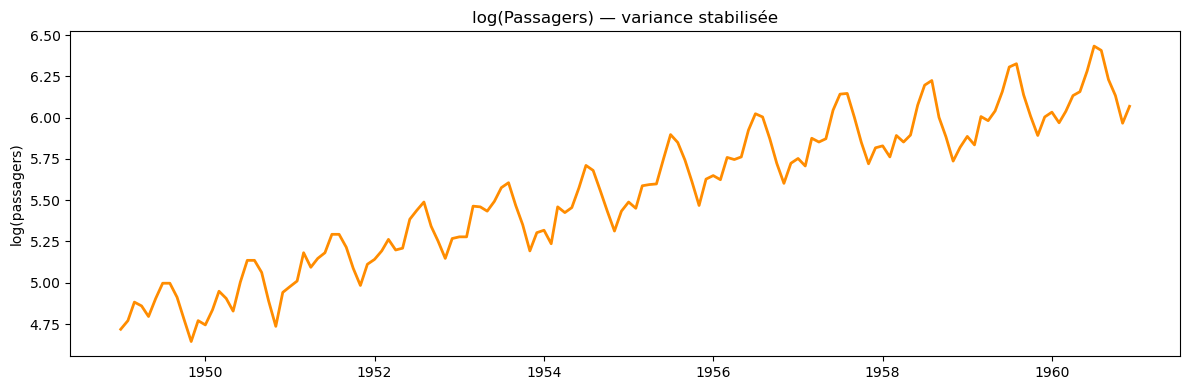

--- log(série) ---
  ADF  : stat=-1.717, p=0.4224  : NON STATIONNAIRE
  KPSS : stat=1.669, p=0.0100  : NON STATIONNAIRE
  (KPSS : p-value plancher 0.01, vraie valeur encore plus petite -> non stationnaire confirmé)



In [318]:
# log transforme le comportement multiplicatif en additif
# Box-Cox avec λ=0 : log(y_t)

log_series = np.log(series)

plt.figure(figsize=(12, 4))
plt.plot(log_series, color='darkorange', lw=2)
plt.title('log(Passagers) — variance stabilisée')
plt.ylabel('log(passagers)')
plt.tight_layout()
plt.show()

test_stationnarite(log_series, "log(série)")

### 2.3 Différenciation — éliminer tendance et saisonnalité

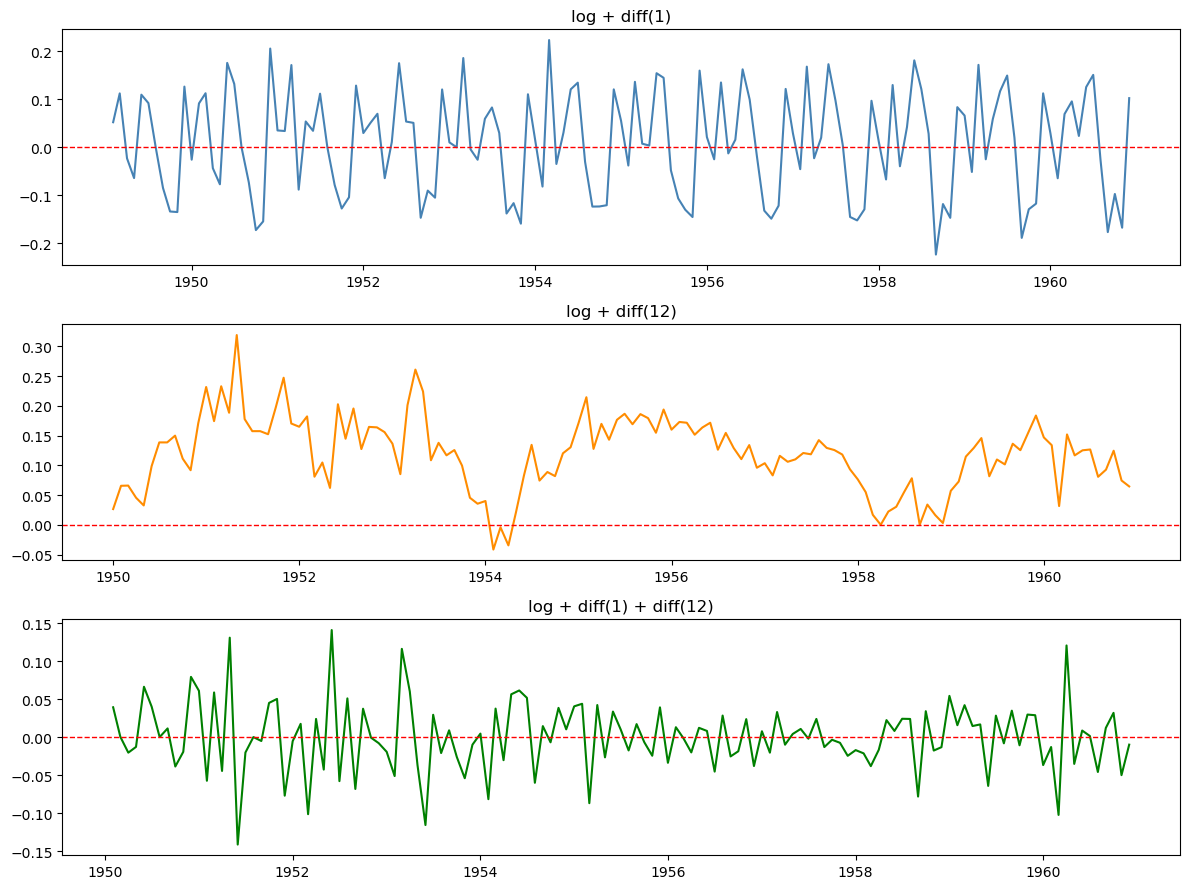

In [321]:
# Opérateur de retard : L·y_t = y_{t-1}
# Diff ordinaire ordre 1 : Δy_t = (1-L)y_t = y_t - y_{t-1}
# Diff saisonnière ordre 12 : Δ₁₂y_t = y_t - y_{t-12}
# On applique les deux sur le log

log_diff1  = log_series.diff(1).dropna()   # enlève tendance
log_sdiff  = log_series.diff(12).dropna()  # enlève saisonnalité
log_both   = log_series.diff(1).diff(12).dropna()  # les deux

fig, axes = plt.subplots(3, 1, figsize=(12, 9))
axes[0].plot(log_diff1, color='steelblue');  axes[0].set_title('log + diff(1)')
axes[1].plot(log_sdiff, color='darkorange'); axes[1].set_title('log + diff(12)')
axes[2].plot(log_both,  color='green');      axes[2].set_title('log + diff(1) + diff(12)')
for ax in axes:
    ax.axhline(0, color='red', ls='--', lw=1)
plt.tight_layout()
plt.show()

In [322]:
# Test de stationnarité sur chaque transformation
test_stationnarite(log_diff1, "log + diff(1)")
test_stationnarite(log_sdiff, "log + diff(12)")
test_stationnarite(log_both,  "log + diff(1) + diff(12)")

# → log + diff(1) + diff(12) doit être stationnaire (ADF p < 0.05)

--- log + diff(1) ---
  ADF  : stat=-2.717, p=0.0711  : NON STATIONNAIRE
  KPSS : stat=0.038, p=0.1000  : STATIONNAIRE

--- log + diff(12) ---
  ADF  : stat=-2.710, p=0.0724  : NON STATIONNAIRE
  KPSS : stat=0.292, p=0.1000  : STATIONNAIRE

--- log + diff(1) + diff(12) ---
  ADF  : stat=-4.443, p=0.0002  : STATIONNAIRE
  KPSS : stat=0.073, p=0.1000  : STATIONNAIRE



### 2.4 ACF et PACF — identifier les ordres p et q

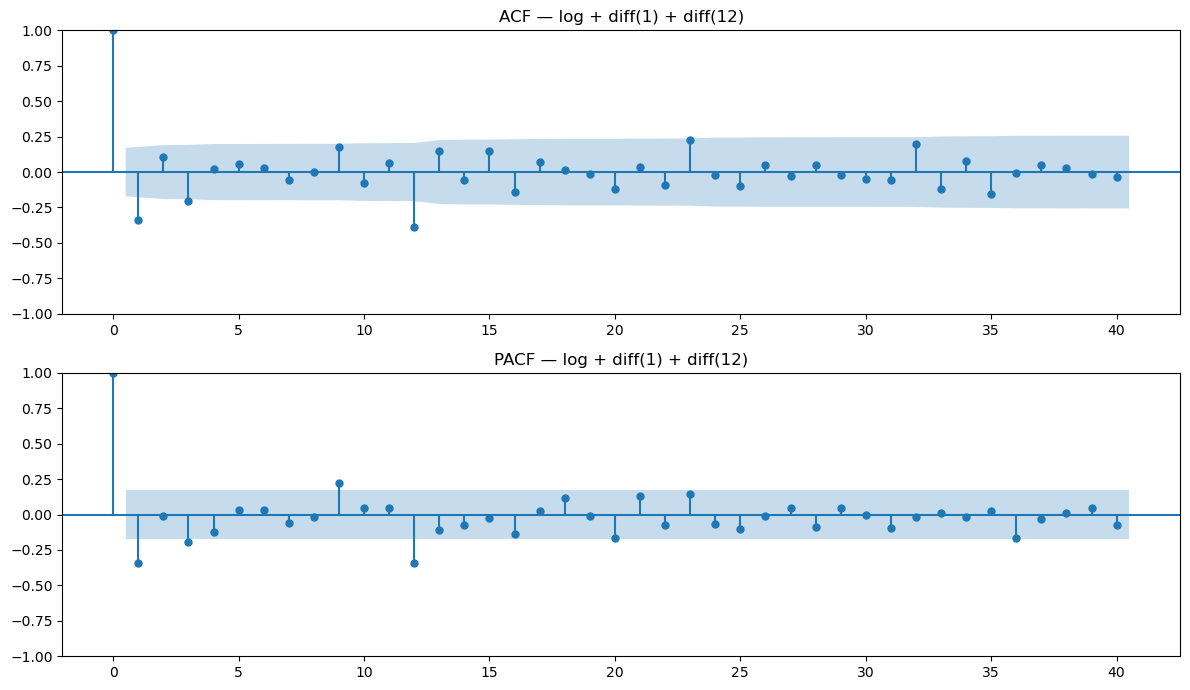

In [326]:
# Série de travail : log + diff(1) + diff(12)
serie_travail = log_both

# ACF : autocorrélation ρ(k) = Cov(y_t, y_{t-k}) / Var(y_t)
# PACF : autocorrélation partielle φ(kk)
# Règles (Brownlee) :
#   AR(p)  : PACF coupe à p, ACF décroît
#   MA(q)  : ACF coupe à q, PACF décroît
#   ARMA   : les deux décroissent

fig, axes = plt.subplots(2, 1, figsize=(12, 7))
plot_acf( serie_travail, lags=40, ax=axes[0])
plot_pacf(serie_travail, lags=40, ax=axes[1], method='ywm')
axes[0].set_title('ACF — log + diff(1) + diff(12)')
axes[1].set_title('PACF — log + diff(1) + diff(12)')
plt.tight_layout()
plt.show()

# Lecture : pic ACF lag=1 → MA(1) ; pic PACF lag=1 → AR(1)
# Pics saisonniers lag=12 → termes SARIMA

### 2.5 Split Train / Test (chronologique)

Train : 132 obs  (1949-01-01 → 1959-12-01)
Test  : 12  obs  (1960-01-01 → 1960-12-01)


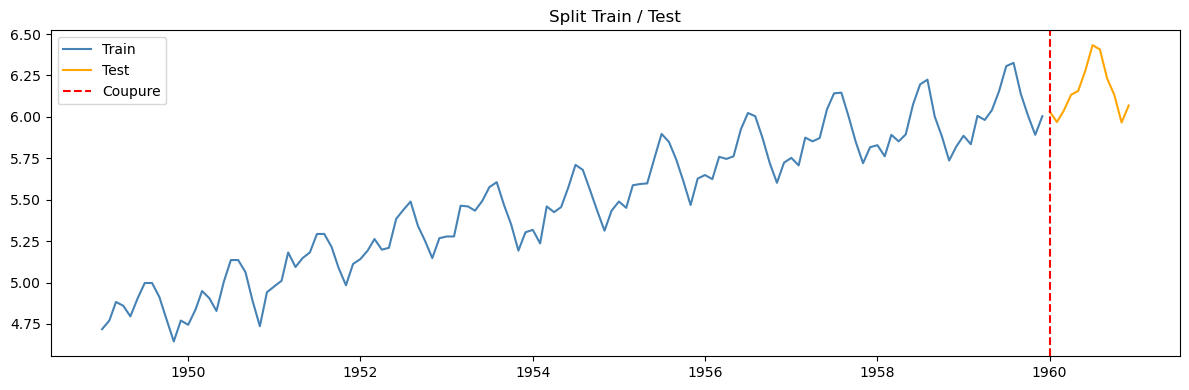

In [329]:
TRAIN_SIZE = 132  # 11 ans train, 1 an test

log_train = log_series[:TRAIN_SIZE]
log_test  = log_series[TRAIN_SIZE:]

print(f"Train : {len(log_train)} obs  ({log_train.index[0].date()} → {log_train.index[-1].date()})")
print(f"Test  : {len(log_test)}  obs  ({log_test.index[0].date()} → {log_test.index[-1].date()})")

plt.figure(figsize=(12, 4))
plt.plot(log_train, color='steelblue', label='Train')
plt.plot(log_test,  color='orange',    label='Test')
plt.axvline(log_test.index[0], color='red', ls='--', lw=1.5, label='Coupure')
plt.title('Split Train / Test')
plt.legend()
plt.tight_layout()
plt.show()

---
## 3. Modélisation

### 3.1 Métriques d'évaluation (NumPy pur)
$$MSE = \frac{1}{n}\sum(y_t-\hat{y}_t)^2 \qquad RMSE = \sqrt{MSE} \qquad MAE = \frac{1}{n}\sum|y_t-\hat{y}_t|$$


In [332]:
def mse(y, yhat):
    return np.mean((np.array(y) - np.array(yhat))**2)

def rmse(y, yhat):
    return np.sqrt(mse(y, yhat))

def mae(y, yhat):
    return np.mean(np.abs(np.array(y) - np.array(yhat)))

def mape(y, yhat):
    y, yhat = np.array(y), np.array(yhat)
    return np.mean(np.abs((y - yhat) / y)) * 100

print("Fonctions métriques définies : mse, rmse, mae, mape")

Fonctions métriques définies : mse, rmse, mae, mape


### 3.2 Baselines (NumPy pur) — tout modèle doit les battre

In [335]:
# Baseline 1 : Naïf : prédit toujours la dernière valeur observée
def baseline_naif(train, n_steps):
    return np.full(n_steps, train.iloc[-1])

# Baseline 2 : Moyenne mobile : moyenne des w derniers mois
def baseline_ma(train, n_steps, w=12):
    return np.full(n_steps, train.iloc[-w:].mean())

pred_naif = baseline_naif(log_train, len(log_test))
pred_ma   = baseline_ma(log_train, len(log_test))

print("=== Performances baselines (espace log) ===")
print(f"Naïf       : RMSE={rmse(log_test, pred_naif):.4f}  MAE={mae(log_test, pred_naif):.4f}  MAPE={mape(log_test, pred_naif):.2f}%")
print(f"MA(12)     : RMSE={rmse(log_test, pred_ma):.4f}  MAE={mae(log_test, pred_ma):.4f}  MAPE={mape(log_test, pred_ma):.2f}%")

=== Performances baselines (espace log) ===
Naïf       : RMSE=0.2124  MAE=0.1625  MAPE=2.59%
MA(12)     : RMSE=0.1836  MAE=0.1371  MAPE=2.19%


### 3.3 AR(p) from scratch — estimation OLS

In [338]:
# Condition stationnarité 

def ar_ols_fit(serie, p):
    vals = serie.values
    T    = len(vals)
    # Colonnes : [1, y_{t-1}, y_{t-2}, ..., y_{t-p}]
    X = np.column_stack(
        [np.ones(T - p)] + [vals[p-i-1 : T-i-1] for i in range(p)]
    )
    y = vals[p:]
    beta = np.linalg.lstsq(X, y, rcond=None)[0]
    return beta

def ar_predict(serie, beta, p, n_steps):
    history = list(serie.values)
    preds   = []
    for _ in range(n_steps):
        x    = [1.0] + [history[-i] for i in range(1, p+1)]
        yhat = np.dot(beta, x)
        preds.append(yhat)
        history.append(yhat)
    return np.array(preds)

# Choisir le meilleur p par RMSE sur le test
for p in range(1, 6):
    beta  = ar_ols_fit(log_train, p)
    preds = ar_predict(log_train, beta, p, len(log_test))
    print(f"AR({p}) scratch : RMSE={rmse(log_test, preds):.4f}  MAPE={mape(log_test, preds):.2f}%")

AR(1) scratch : RMSE=0.2663  MAPE=3.44%
AR(2) scratch : RMSE=0.2861  MAPE=3.75%
AR(3) scratch : RMSE=0.2523  MAPE=3.19%
AR(4) scratch : RMSE=0.2368  MAPE=2.96%
AR(5) scratch : RMSE=0.1839  MAPE=2.32%


In [340]:
# Retenir le meilleur p (ici on fixe p=2 pour l'exemple, adapter selon résultats)
best_p = 2
beta_ar = ar_ols_fit(log_train, best_p)
ar_preds = ar_predict(log_train, beta_ar, best_p, len(log_test))

print(f"Paramètres AR({best_p}) : {beta_ar.round(4)}")
print(f"  Interprétation : φ₁={beta_ar[1]:.4f} : mémoire du mois précédent")

Paramètres AR(2) : [ 0.2526  1.161  -0.2056]
  Interprétation : φ₁=1.1610 : mémoire du mois précédent


### 3.4 MA(q) from scratch — optimisation numérique

In [343]:
# Les résidus ε sont latents -> estimation par minimisation de la somme des carrés

from scipy.optimize import minimize

def ma_residuals(params, vals, q):
    mu    = params[0]
    theta = params[1:q+1]
    n     = len(vals)
    resid = np.zeros(n)
    for t in range(n):
        err = vals[t] - mu
        for j in range(1, min(t, q) + 1):
            err -= theta[j-1] * resid[t-j]
        resid[t] = err
    return resid

def ma_loss(params, vals, q):
    return np.sum(ma_residuals(params, vals, q)**2)

def ma_fit(serie, q):
    vals = serie.values
    x0   = np.zeros(q + 1)
    x0[0] = vals.mean()
    opt  = minimize(ma_loss, x0, args=(vals, q), method='Nelder-Mead',
                    options={'maxiter': 5000})
    return opt.x

# MA(1)
params_ma1 = ma_fit(log_train, 1)
mu_hat     = params_ma1[0]
theta1     = params_ma1[1]
# Prévision MA(q) à h > q = μ (espérance)
ma_preds   = np.full(len(log_test), mu_hat)

print(f"MA(1) scratch : μ={mu_hat:.4f}, θ₁={theta1:.4f}")
print(f"  RMSE={rmse(log_test, ma_preds):.4f}  MAPE={mape(log_test, ma_preds):.2f}%")
print("  Note : prévision MA(q) à h>q converge vers μ -> limité pour longues prévisions")

MA(1) scratch : μ=5.4679, θ₁=0.8651
  RMSE=0.7025  MAPE=11.10%
  Note : prévision MA(q) à h>q converge vers μ -> limité pour longues prévisions


### 3.5 ARIMA avec statsmodels — grid search AIC

In [346]:
# d=0 car déjà différenciée manuellement
# AIC = -2·log(L̂) + 2k  ->  minimiser

best_aic   = np.inf
best_order = (1, 0, 1)

print("Grid search ARIMA(p, 0, q) :")
for p in range(0, 4):
    for q in range(0, 4):
        try:
            m = ARIMA(log_train, order=(p, 0, q)).fit()
            print(f"  ARIMA({p},0,{q}) : AIC={m.aic:.2f}")
            if m.aic < best_aic:
                best_aic, best_order = m.aic, (p, 0, q)
        except:
            pass

print(f"\n Meilleur : ARIMA{best_order}  AIC={best_aic:.2f}")

Grid search ARIMA(p, 0, q) :
  ARIMA(0,0,0) : AIC=146.19
  ARIMA(0,0,1) : AIC=-7.14
  ARIMA(0,0,2) : AIC=-89.11
  ARIMA(0,0,3) : AIC=-157.89
  ARIMA(1,0,0) : AIC=-208.71
  ARIMA(1,0,1) : AIC=-214.54
  ARIMA(1,0,2) : AIC=-215.52
  ARIMA(1,0,3) : AIC=-214.76
  ARIMA(2,0,0) : AIC=-212.72
  ARIMA(2,0,1) : AIC=-218.31
  ARIMA(2,0,2) : AIC=-216.57
  ARIMA(2,0,3) : AIC=-216.85
  ARIMA(3,0,0) : AIC=-213.57
  ARIMA(3,0,1) : AIC=-216.56
  ARIMA(3,0,2) : AIC=-221.44
  ARIMA(3,0,3) : AIC=-219.75

 Meilleur : ARIMA(3, 0, 2)  AIC=-221.44


In [347]:
arima_model = ARIMA(log_train, order=best_order).fit()
arima_preds = arima_model.forecast(steps=len(log_test))

print(arima_model.summary())
print(f"\nARIMA{best_order} : RMSE={rmse(log_test, arima_preds):.4f}  MAPE={mape(log_test, arima_preds):.2f}%")

                               SARIMAX Results                                
Dep. Variable:             passengers   No. Observations:                  132
Model:                 ARIMA(3, 0, 2)   Log Likelihood                 117.722
Date:                Sun, 10 May 2026   AIC                           -221.444
Time:                        21:41:49   BIC                           -201.264
Sample:                    01-01-1949   HQIC                          -213.244
                         - 12-01-1959                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.2856      0.396     13.332      0.000       4.509       6.063
ar.L1         -0.0992      0.078     -1.278      0.201      -0.251       0.053
ar.L2          0.2780      0.075      3.726      0.0

### 3.6 SARIMA — modèle principal (saisonnalité explicite)

In [349]:
# On travaille sur log_series (pas encore différenciée) et SARIMA gère d=1, D=1

# Ordre de départ basé sur ACF/PACF : SARIMA(1,1,1)(1,1,1)[12]

sarima_model = SARIMAX(
    log_train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

sarima_preds_log = sarima_model.forecast(steps=len(log_test))

# Repasser en espace original
sarima_preds_orig = np.exp(sarima_preds_log)
test_orig         = np.exp(log_test)

print(sarima_model.summary())
print(f"\nSARIMA(1,1,1)(1,1,1)[12] :")
print(f"  RMSE (log)      = {rmse(log_test, sarima_preds_log):.4f}")
print(f"  RMSE (passagers)= {rmse(test_orig, sarima_preds_orig):.2f} milliers")
print(f"  MAPE            = {mape(test_orig, sarima_preds_orig):.2f}%")

                                     SARIMAX Results                                      
Dep. Variable:                         passengers   No. Observations:                  132
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                 196.914
Date:                            Sun, 10 May 2026   AIC                           -383.829
Time:                                    21:41:51   BIC                           -370.559
Sample:                                01-01-1949   HQIC                          -378.451
                                     - 12-01-1959                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0946      0.235      0.402      0.688      -0.367       0.556
ma.L1         -0.4997      0.213   

### 3.7 Grid search SARIMA 

In [351]:
best_aic_s, best_sarima_order = np.inf, (1, 1, 1)

print("Grid search SARIMA(p,1,q)(1,1,1)[12] :")
for p in [0, 1, 2]:
    for q in [0, 1, 2]:
        try:
            m = SARIMAX(
                log_train,
                order=(p, 1, q),
                seasonal_order=(1, 1, 1, 12),
                enforce_stationarity=False,
                enforce_invertibility=False
            ).fit(disp=False)
            print(f"  SARIMA({p},1,{q})(1,1,1)[12] : AIC={m.aic:.2f}")
            if m.aic < best_aic_s:
                best_aic_s, best_sarima_order = m.aic, (p, 1, q)
        except:
            pass

print(f"\n -> Meilleur : SARIMA{best_sarima_order}(1,1,1)[12]  AIC={best_aic_s:.2f}")

Grid search SARIMA(p,1,q)(1,1,1)[12] :
  SARIMA(0,1,0)(1,1,1)[12] : AIC=-375.71
  SARIMA(0,1,1)(1,1,1)[12] : AIC=-385.78
  SARIMA(0,1,2)(1,1,1)[12] : AIC=-379.93
  SARIMA(1,1,0)(1,1,1)[12] : AIC=-388.68
  SARIMA(1,1,1)(1,1,1)[12] : AIC=-383.83
  SARIMA(1,1,2)(1,1,1)[12] : AIC=-380.82
  SARIMA(2,1,0)(1,1,1)[12] : AIC=-383.30
  SARIMA(2,1,1)(1,1,1)[12] : AIC=294.86
  SARIMA(2,1,2)(1,1,1)[12] : AIC=-379.25

 -> Meilleur : SARIMA(1, 1, 0)(1,1,1)[12]  AIC=-388.68


In [352]:
# Réajuster le meilleur SARIMA
best_sarima = SARIMAX(
    log_train,
    order=best_sarima_order,
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

best_preds_log  = best_sarima.forecast(steps=len(log_test))
best_preds_orig = np.exp(best_preds_log)

print(f"Meilleur SARIMA{best_sarima_order}(1,1,1)[12] :")
print(f"  RMSE (passagers) = {rmse(test_orig, best_preds_orig):.2f}")
print(f"  MAPE             = {mape(test_orig, best_preds_orig):.2f}%")

Meilleur SARIMA(1, 1, 0)(1,1,1)[12] :
  RMSE (passagers) = 16.66
  MAPE             = 2.55%


---
## 4. Évaluation et Diagnostic

### 4.1 Tableau comparatif des performances


In [354]:
# Récapitulatif 
print(f"{'Modèle':<35} {'RMSE':>8} {'MAE':>8} {'MAPE%':>8}")
print("-" * 62)

modeles = {
    'Baseline naïf':         pred_naif,
    'Baseline MA(12)':       pred_ma,
    f'AR({best_p}) scratch': ar_preds,
    f'ARIMA{best_order}':    arima_preds.values,
    'SARIMA(1,1,1)(1,1,1)[12]': sarima_preds_log.values,
    f'SARIMA{best_sarima_order}(1,1,1)[12] (best)': best_preds_log.values,
}

for nom, preds in modeles.items():
    r = rmse(log_test, preds)
    m = mae(log_test, preds)
    mp = mape(log_test, preds)
    print(f"{nom:<35} {r:>8.4f} {m:>8.4f} {mp:>8.2f}")

Modèle                                  RMSE      MAE    MAPE%
--------------------------------------------------------------
Baseline naïf                         0.2124   0.1625     2.59
Baseline MA(12)                       0.1836   0.1371     2.19
AR(2) scratch                         0.2861   0.2342     3.75
ARIMA(3, 0, 2)                        0.2837   0.2321     3.71
SARIMA(1,1,1)(1,1,1)[12]              0.0317   0.0228     0.37
SARIMA(1, 1, 0)(1,1,1)[12] (best)     0.0352   0.0250     0.41


### 4.2 Visualisation des prévisions vs réel

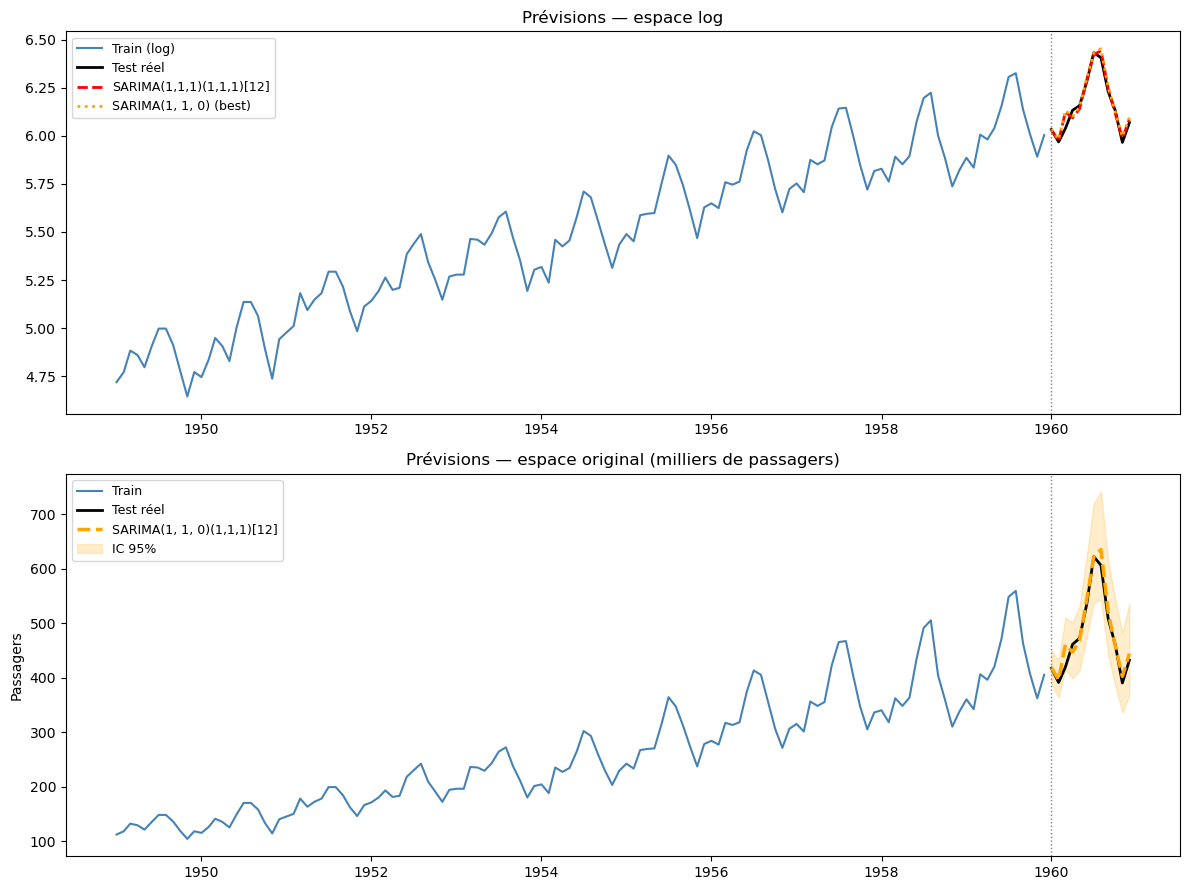

In [357]:
fig, axes = plt.subplots(2, 1, figsize=(12, 9))

ax = axes[0]
ax.plot(log_train, color='steelblue', label='Train (log)', lw=1.5)
ax.plot(log_test,  color='black',     label='Test réel',   lw=2)
ax.plot(log_test.index, sarima_preds_log, color='red',    ls='--', lw=2, label='SARIMA(1,1,1)(1,1,1)[12]')
ax.plot(log_test.index, best_preds_log,   color='orange', ls=':',  lw=2, label=f'SARIMA{best_sarima_order} (best)')
ax.axvline(log_test.index[0], color='gray', ls=':', lw=1)
ax.set_title('Prévisions — espace log')
ax.legend(fontsize=9)

#Espace original 
ax = axes[1]
ax.plot(np.exp(log_train), color='steelblue', label='Train',      lw=1.5)
ax.plot(test_orig,         color='black',     label='Test réel',  lw=2)
ax.plot(log_test.index, best_preds_orig,     color='orange', ls='--', lw=2.5,
        label=f'SARIMA{best_sarima_order}(1,1,1)[12]')

# Intervalle de confiance
fc_obj = best_sarima.get_forecast(steps=len(log_test))
ci     = np.exp(fc_obj.conf_int())
ax.fill_between(log_test.index, ci.iloc[:,0], ci.iloc[:,1],
                alpha=0.2, color='orange', label='IC 95%')

ax.axvline(log_test.index[0], color='gray', ls=':', lw=1)
ax.set_title('Prévisions — espace original (milliers de passagers)')
ax.legend(fontsize=9)
ax.set_ylabel('Passagers')

plt.tight_layout()
plt.show()

### 4.3 Analyse des résidus du modèle final

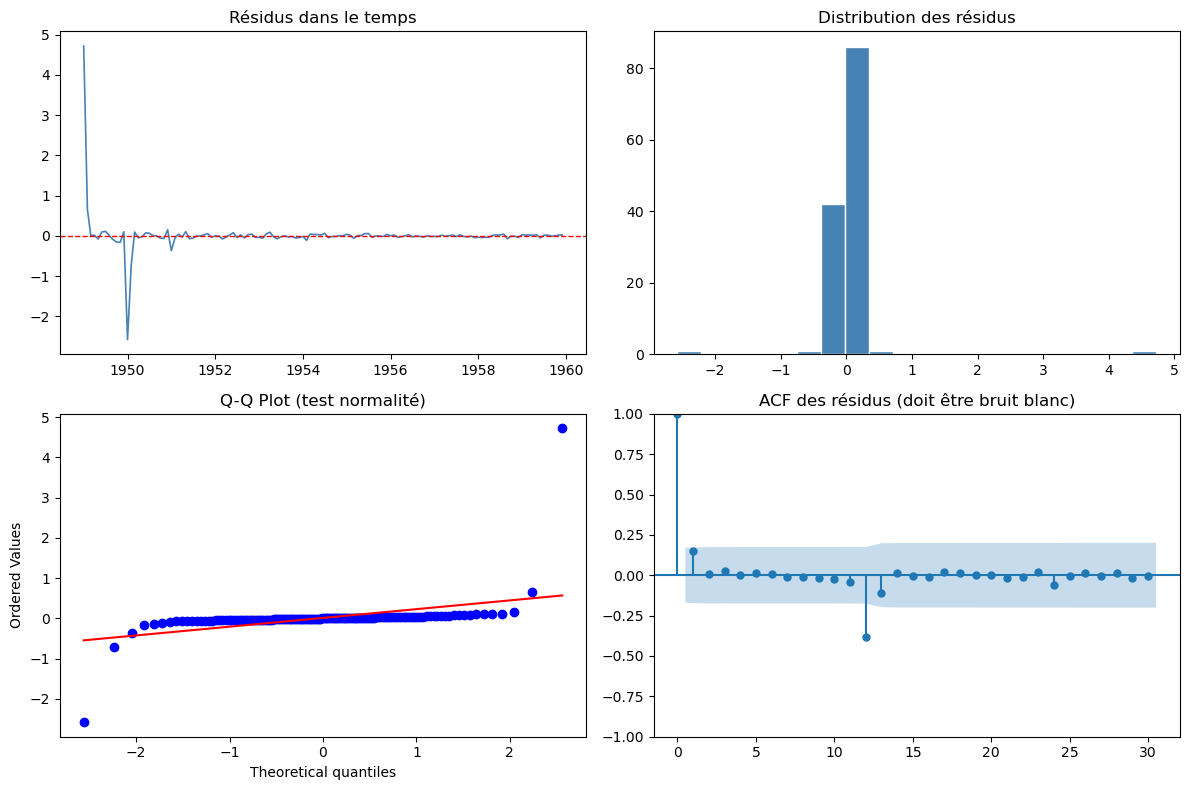

In [360]:
resid = best_sarima.resid.dropna()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Résidus dans le temps
axes[0,0].plot(resid, color='steelblue', lw=1.2)
axes[0,0].axhline(0, color='red', ls='--', lw=1)
axes[0,0].set_title('Résidus dans le temps')

# Histogramme
axes[0,1].hist(resid, bins=20, color='steelblue', edgecolor='white')
axes[0,1].set_title('Distribution des résidus')

# Q-Q plot (normalité)
stats.probplot(resid, dist='norm', plot=axes[1,0])
axes[1,0].set_title('Q-Q Plot (test normalité)')

# ACF des résidus
plot_acf(resid, lags=30, ax=axes[1,1])
axes[1,1].set_title('ACF des résidus (doit être bruit blanc)')

plt.tight_layout()
plt.show()

### 4.4 Test de Ljung-Box

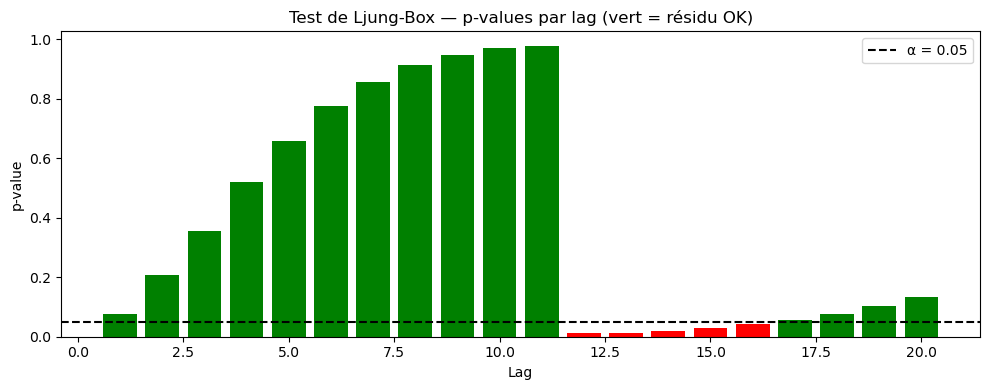

p-values Ljung-Box :
1     0.0759
2     0.2063
3     0.3572
4     0.5198
5     0.6600
6     0.7752
7     0.8576
8     0.9143
9     0.9490
10    0.9696
11    0.9784
12    0.0139
13    0.0126
14    0.0193
15    0.0288
16    0.0414
17    0.0570
18    0.0771
19    0.1022
20    0.1324

Min p-value : 0.0126
Autocorrélation résiduelle détectée (envisager un ordre supérieur)


In [362]:
# Si p-value > 0.05 -> résidus OK

lb = acorr_ljungbox(resid, lags=list(range(1, 21)), return_df=True)

plt.figure(figsize=(10, 4))
colors = ['green' if p > 0.05 else 'red' for p in lb['lb_pvalue']]
plt.bar(lb.index, lb['lb_pvalue'], color=colors)
plt.axhline(0.05, color='black', ls='--', lw=1.5, label='α = 0.05')
plt.title('Test de Ljung-Box — p-values par lag (vert = résidu OK)')
plt.xlabel('Lag')
plt.ylabel('p-value')
plt.legend()
plt.tight_layout()
plt.show()

print("p-values Ljung-Box :")
print(lb['lb_pvalue'].round(4).to_string())
print(f"\nMin p-value : {lb['lb_pvalue'].min():.4f}")
print("→ OK" if lb['lb_pvalue'].min() > 0.05 else "Autocorrélation résiduelle détectée (envisager un ordre supérieur)")

### 4.5 Walk-Forward Validation

Walk-forward validation en cours...
Walk-forward RMSE = 0.0365 (log)
Walk-forward MAE  = 0.0283 (log)


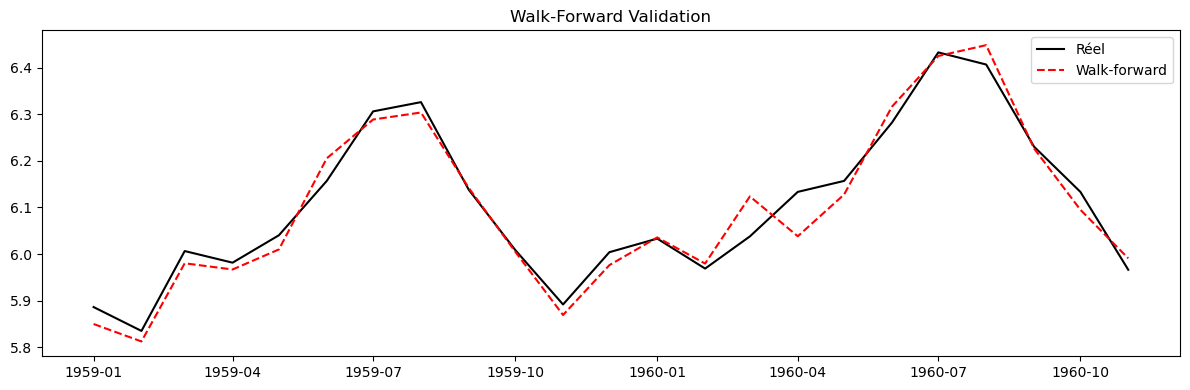

In [364]:
# Expanding window : train grandit d'une observation à chaque itération

print("Walk-forward validation en cours...")

wf_actual = []
wf_preds  = []
wf_start  = 120  # 10 ans de train minimum

for t in range(wf_start, len(log_series) - 1):
    train_wf = log_series[:t]
    try:
        m = SARIMAX(
            train_wf,
            order=best_sarima_order,
            seasonal_order=(1, 1, 1, 12),
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(disp=False)
        wf_preds.append(m.forecast(1).iloc[0])
        wf_actual.append(log_series.iloc[t])
    except:
        pass

wf_rmse = rmse(wf_actual, wf_preds)
wf_mae  = mae(wf_actual, wf_preds)
print(f"Walk-forward RMSE = {wf_rmse:.4f} (log)")
print(f"Walk-forward MAE  = {wf_mae:.4f} (log)")

plt.figure(figsize=(12, 4))
plt.plot(log_series.index[wf_start:wf_start+len(wf_actual)], wf_actual, color='black', label='Réel')
plt.plot(log_series.index[wf_start:wf_start+len(wf_preds)],  wf_preds,  color='red', ls='--', label='Walk-forward')
plt.title('Walk-Forward Validation')
plt.legend()
plt.tight_layout()
plt.show()

---
## 5. Conclusion

### 5.1 Synthèse des résultats


In [367]:
print("=" * 60)
print("SYNTHÈSE FINALE")
print("=" * 60)
print(f"Dataset          : Monthly Airline Passengers (1949–1960)")
print(f"Modèle retenu    : SARIMA{best_sarima_order}(1,1,1)[12] sur log(série)")
print(f"Transformation   : log + SARIMA intègre d=1, D=1 en interne")
print()
print("Performances modèle final sur test 1960 :")
print(f"  RMSE (passagers) = {rmse(test_orig, best_preds_orig):.2f} milliers")
print(f"  MAE  (passagers) = {mae(test_orig, best_preds_orig):.2f} milliers")
print(f"  MAPE             = {mape(test_orig, best_preds_orig):.2f}%")
print()
print("Paramètres estimés :")
print(best_sarima.summary().tables[1])

SYNTHÈSE FINALE
Dataset          : Monthly Airline Passengers (1949–1960)
Modèle retenu    : SARIMA(1, 1, 0)(1,1,1)[12] sur log(série)
Transformation   : log + SARIMA intègre d=1, D=1 en interne

Performances modèle final sur test 1960 :
  RMSE (passagers) = 16.66 milliers
  MAE  (passagers) = 11.89 milliers
  MAPE             = 2.55%

Paramètres estimés :
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3821      0.075     -5.096      0.000      -0.529      -0.235
ar.S.L12      -0.3540      0.153     -2.321      0.020      -0.653      -0.055
ma.S.L12      -0.1736      0.187     -0.931      0.352      -0.539       0.192
sigma2         0.0014      0.000      7.698      0.000       0.001       0.002


### 5.2 Interprétation métier

Le modèle révèle que le trafic aérien de 1949–1960 est régi par :

1. **Tendance exponentielle** : croissance régulière (introduction Boeing 707 en 1958)  
2. **Saisonnalité forte** : pics juillet–août, creux janvier–février (vacances d'été)  
3. **Comportement multiplicatif** : l'amplitude des oscillations croît avec le niveau  
4. **Mémoire à court terme** (MA(1)) : correction sur l'erreur du mois précédent

### 5.3 Limites et pistes d'amélioration

- Ljung-Box peut signaler une légère autocorrélation résiduelle → essayer SARIMA(1,1,2) ou (2,1,1)
- Non-normalité des résidus → erreurs à queues épaisses (t-distribution)
- Variables exogènes (PIB, prix pétrole) → passer à un modèle **SARIMAX**
- Comparaison avec méthodes modernes : **Prophet**, **LSTM**, **N-BEATS**
